<a href="https://colab.research.google.com/github/taisei0223/QI4U-hands-on/blob/main/hands_on_basic_ideas_of_qiskit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **QI4U2026@University of Warsaw  Hands-on Day 2**
Welcome to QI4U at UW！In this notebook, we learn how to use Qiskit.

Let's operate qubits using Qiskit.
#### References
- John Watrous, *Basics of Quantum Information*, IBM Quantum Learning.  
  https://quantum.cloud.ibm.com/learning/ja/courses/basics-of-quantum-information

- Qiskit Global Summer School 2025 Lab0
  https://github.com/qiskit-community/qgss-2025/blob/main/lab-0/lab0_ja.ipynb

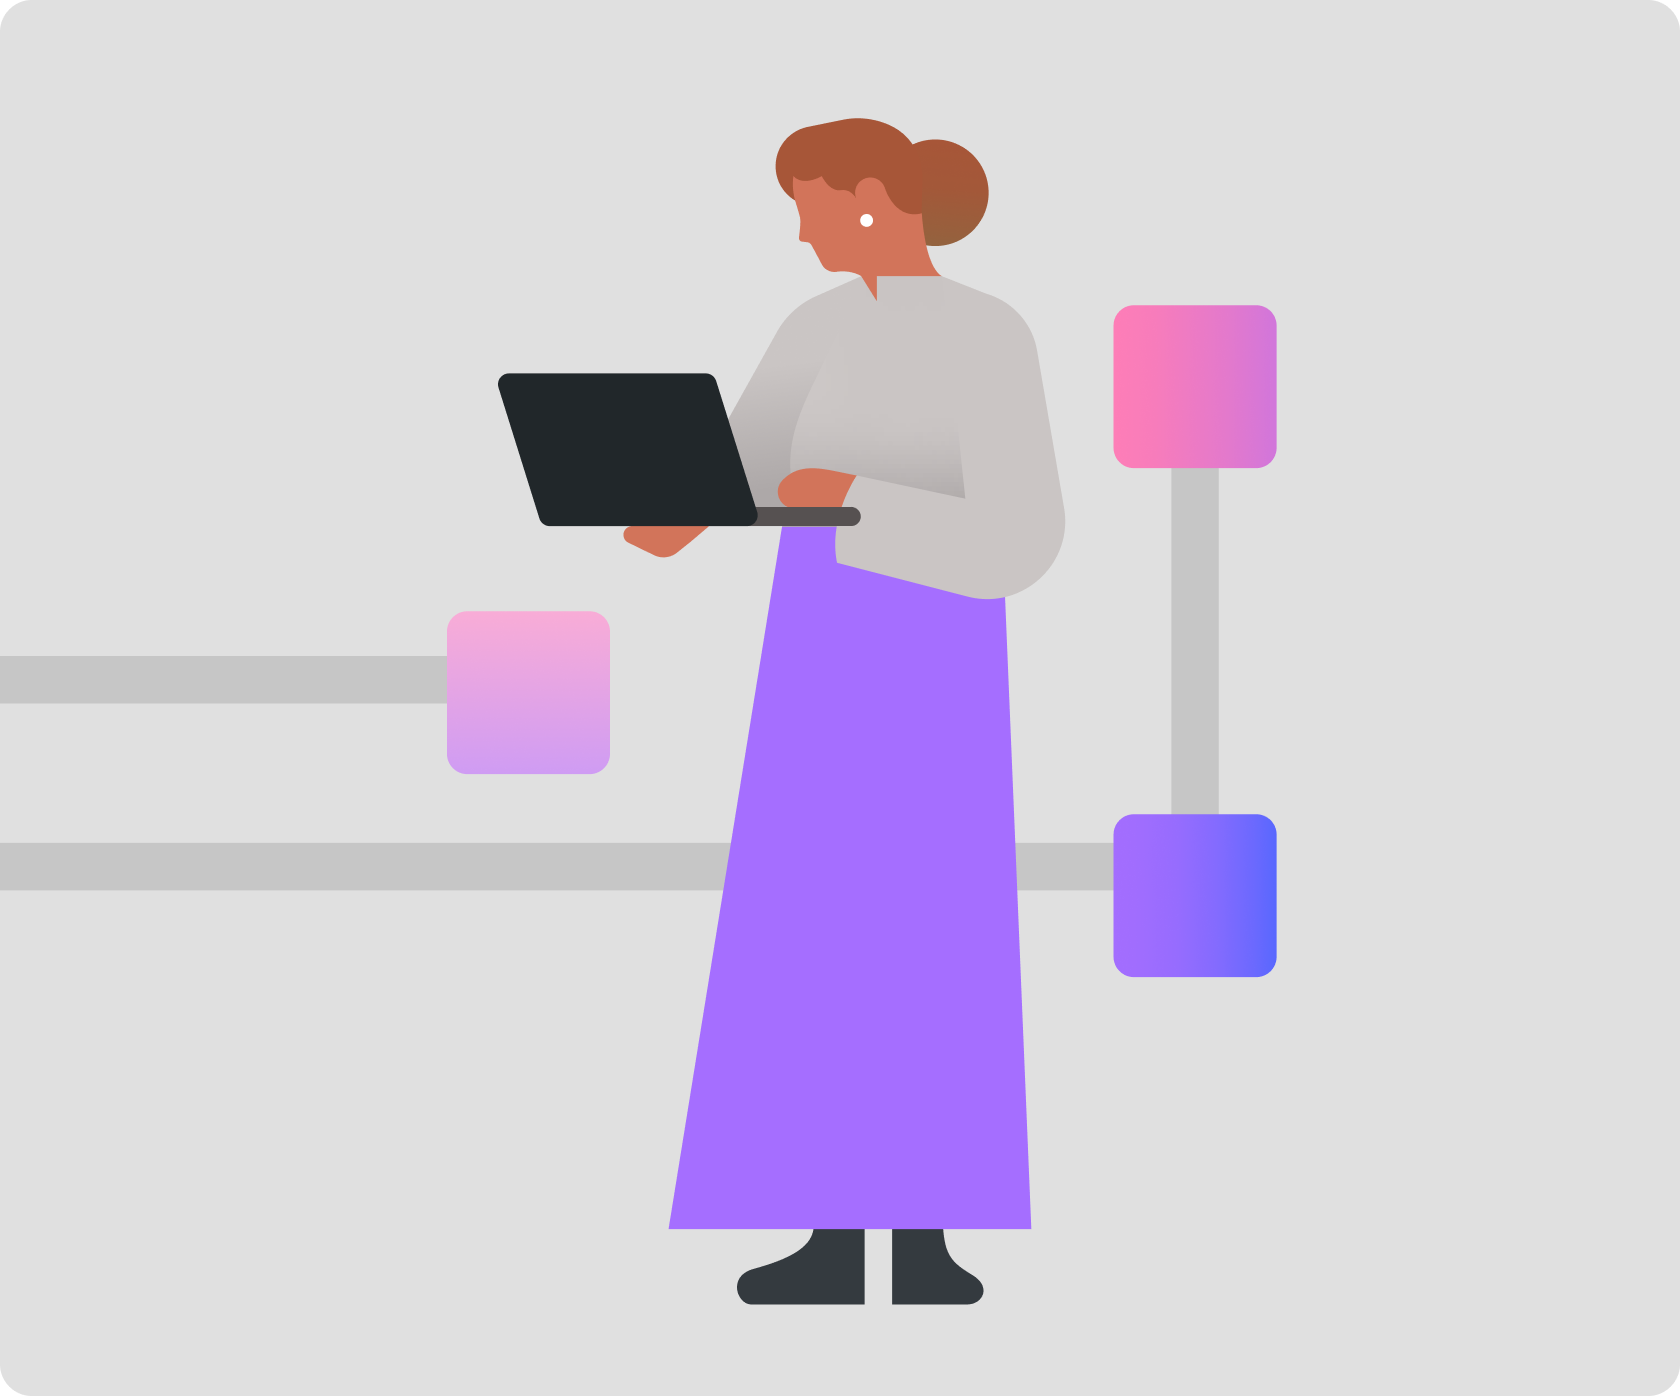

## Install Qiskit
Quantum Computing is expected to be  the greatest technological  game changer in the history of computing.

Applying Shor's algorithm could break modern encryption, while Grover's algorithm provides a significant speedup for lookups.

To master these powerful tools, learning Qiskit is an excellent first step.

### Qiskit Library
- `qiskit[visualization]`: Display measurement results in a histogram and Visualize the quantum states or quantum circuit.
- `qiskit-ibm-runtime`: Provide a sampler to retrieve measurement results from both simulators and IBM's real quantum hardware.
- `qiskit-aer`: high-performance simulator framework for quantum circuits. It allows you to incorporate realistic noise model to mimic the behavior of actual quantum hardware.

In [14]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer

## Import necessary classes and functions

- `QuantumCircuit`: Class for quantum circuit description（[API References](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)）
- `AerSimulator`: High-quality simulator of quantum computing（[API Documentation](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html#aersimulator)）
- `generate_preset_pass_manager`: Class for reconstruction of virtual quantum circuit into realizable ones. ([API References](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager))
- `SamplerV2`: Class for sampling data as interface for backends that execute quantum circuits.([API References](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/sampler-v2))
- `plot_histogram`: Function for visualization of the measurement results with histogram.([API References](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.plot_histogram))


In [15]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
import numpy as np
# An in-house assessment tool
!wget -O grader.py https://raw.githubusercontent.com/taigasuzuki1148/QQF_2025_science_tokyo/refs/heads/main/Hands-on/grader.py
!wget -O circle_notation.py https://raw.githubusercontent.com/taigasuzuki1148/QQF_2025_science_tokyo/refs/heads/main/Hands-on/circle_notation.py

--2026-03-02 13:49:32--  https://raw.githubusercontent.com/taigasuzuki1148/QQF_2025_science_tokyo/refs/heads/main/Hands-on/grader.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6072 (5.9K) [text/plain]
Saving to: ‘grader.py’

grader.py           100%[===================>]   5.93K  --.-KB/s    in 0s      

2026-03-02 13:49:32 (49.0 MB/s) - ‘grader.py’ saved [6072/6072]

--2026-03-02 13:49:32--  https://raw.githubusercontent.com/taigasuzuki1148/QQF_2025_science_tokyo/refs/heads/main/Hands-on/circle_notation.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiti

##**Quantum Circuit of single qubit**

### Preparation for quantum state$|0\rangle$
In Qiskit, the default quantum state by **QuantumCircuit** is $|0\rangle$

**QuantumCircuit(Number of qubits)** means $|0\rangle...|0\rangle$

Example:

If your circuit is named **qc**,and you wanna prepare **one qubit** system:
- **qc=QuantumCircuit(1)**

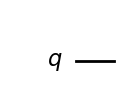

In [16]:
# Quantum circuits initialize to state |0> by default,
# so we simply need to prepare the circuit.
qc = QuantumCircuit(1) # QuantumCircuit(number of qubits)
# Visualize the circuit
qc.draw('mpl', style="clifford")

### Applying Quantum Gates
To apply a quantum gate to a circuit, follow this syntax:
- **(circuit_name).(gate_method)(qubit_index)**

Example:

If your circuit is named **qc**,and you wanna apply an **X gate** to the **first qubit(index 0)**:
- **qc.x(0)**

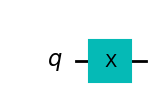

In [17]:
# Prepare state |0>
qc = QuantumCircuit(1)
# X gate
# Inside x(), specify the index of the target qubit.
# Since we have only one, we specify index 0.
qc.x(0)

# Visualize the circuit
qc.draw('mpl', style="clifford")

Other gates can be applied using a similar syntax:
- qc.y(0)
- qc.z(0)
- qc.h(0)


<a id="Exercise_1"></a>
<div class="alert alert-block alert-success">

<b>Exercise 1: Let's Build the Following Quantum Circuit!</b>

It's finally time for our first hands-on exercise! How exciting!

In this exercise, your task is to design a quantum circuit that matches the one shown below.

</div>

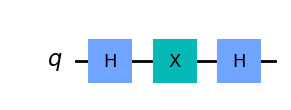

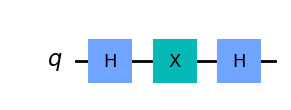

In [22]:
# Create a new single-qubit circuit
qc_ex1 = QuantumCircuit(1)

### WRITE YOUR CODE BELOW HERE ###
qc_ex1.h(0)
qc_ex1.x(0)
qc_ex1.h(0)
### WRITE YOUR CODE ABOVE HERE ###

# Render the circuit using MatPlotLib ("mpl")
qc_ex1.draw('mpl', style="clifford")

In [23]:
# grader, You can check your Answer by conducting this cell
from IPython.utils import io
from grader import create_circuit
with io.capture_output() as captured:
    create_circuit(qc_ex1)
english_output = captured.stdout.replace('不正解です', 'Incorrect').replace('正解です', 'Correct')
print(english_output)

Correct！



In fact, **HXH gates = Z gate**!


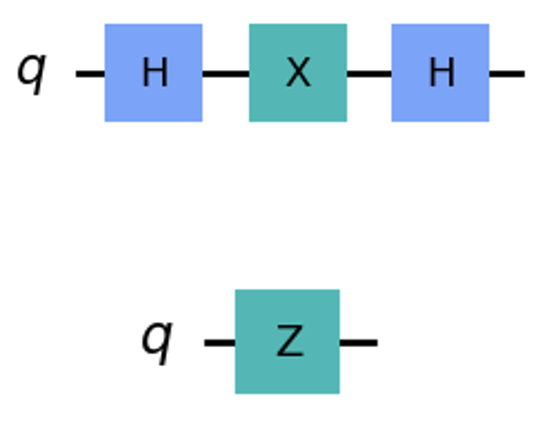

<a id="Exercise_3"></a>
<div class="alert alert-block alert-success">

<b>Exercise 2: Create a Quantum Circuit with 50% Probability for 0 and 1 !</b>

In this exercise, design a state by following these steps:

1. Use only one qubit.
2. Apply a specific quantum gate to the qubit. (Think about which gate is most suitable for this!)

</div>

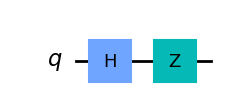

In [24]:
### WRITE YOUR CODE BELOW HERE ###
qc_ex2 = QuantumCircuit(1)
qc_ex2.h(0)
qc_ex2.z(0)
### WRITE YOUR CODE ABOVE HERE ###

# Render the circuit using MatPlotLib ("mpl")
qc_ex2.draw('mpl', style="clifford")

In [25]:
# grader, You can check your Answer by conducting this cell
from IPython.utils import io
from grader import grade_equal_superposition_amplitude
with io.capture_output() as captured:
    grade_equal_superposition_amplitude(qc_ex2)
english_output = captured.stdout.replace('不正解です', 'Incorrect').replace('正解です！他にも解答はあります！いろんなゲートを作用させてみよう！', 'Correct')
print(english_output)

Correct



### Let's run an experiment to see if our circuit actually detects 0 and 1 with a 50% probability!

Measurement counts: {'1': 2538, '0': 2462}


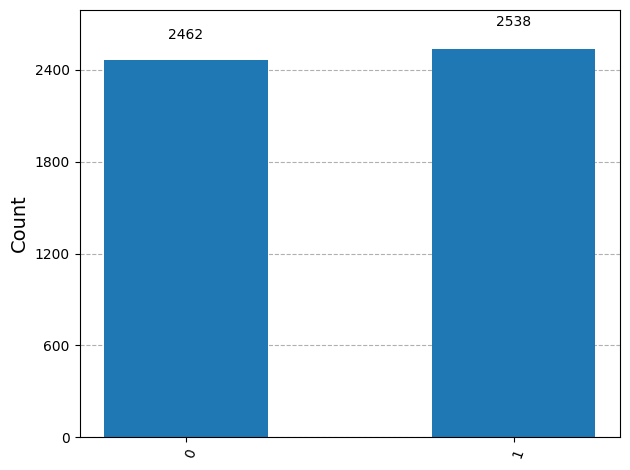

In [26]:
# Perform measurement
qc_ex2.measure_all()

# Select the simulator
# Instead of using a real quantum computer,
# we use a backend that emulates its behavior.
backend = AerSimulator()

# Configure settings for transpilation (optimization for hardware/simulators)
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
# Create the transpiled (ISA) quantum circuit
isa_qc_ex2 = pm.run(qc_ex2)

# Define the Sampler
# (We're just sampling here, but Samplers are quite handy as some can directly output probability distributions.)
sampler = Sampler(mode=backend)

# Number of measurement shots
shots = 5000
# Run the simulation with the specified settings
job = sampler.run([isa_qc_ex2], shots=shots)
result = job.result()

counts = result[0].data.meas.get_counts()
print(f'Measurement counts: {counts}')
hist = plot_histogram(counts)
hist

## 2-qubit Quantum Circuits
### 2-qubit Computation 1
As we saw in the lecture, we can apply quantum gates to each individual qubit. First, let's practice applying gates to qubits one by one!

Similarly, to apply a gate to the circuit, use the following syntax:

- **(circuit_name).(gate_method)(qubit_index)**

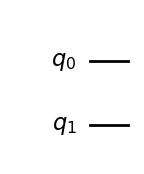

In [27]:
#create 2-qubit state
qc2=QuantumCircuit(2)
#Visualize the circuit
qc2.draw('mpl', style="clifford")

<a id="Exercise_4"></a>
<div class="alert alert-block alert-success">

<b>Exercise 3 (A bit challenging): In the code cell below, create a quantum circuit where all states are detected with a probability of 1/4!</b>

In this exercise, please design a quantum circuit that outputs the following quantum state

</div>

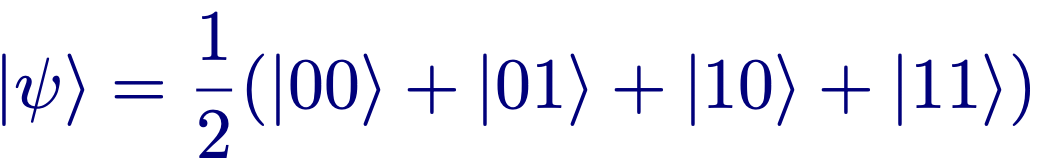

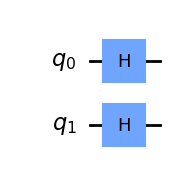

In [28]:
# Create a new 2-qubit circuit
qc_ex3 = QuantumCircuit(2)

### WRITE YOUR CODE BELOW ###

qc_ex3.h(0)
qc_ex3.h(1)

### WRITE YOUR CODE ABOVE HERE ###

# Render the circuit using MatPlotLib ("mpl")
qc_ex3.draw('mpl', style="clifford")

In [29]:
# grader, You can check your Answer by conducting this cell
from IPython.utils import io
from grader import grade_2qubit1
with io.capture_output() as captured:
    grade_2qubit1(qc_ex3)
english_output = captured.stdout.replace('不正解です', 'Incorrect').replace('正解です', 'Correct')
print(english_output)

Correct！



### Let's run an experiment to see if your circuit actually results in 00, 01, 10, and 11 being detected with a 25% probability!

Measurement counts: {'11': 1212, '01': 1299, '10': 1271, '00': 1218}


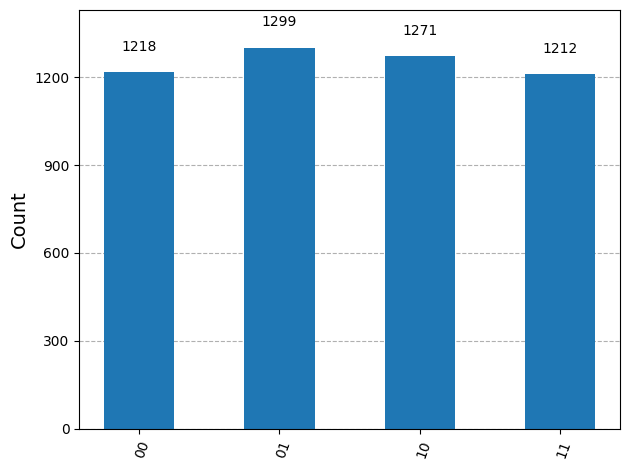

In [30]:
# Perform measurement
qc_ex3.measure_all()
backend = AerSimulator()

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc_ex3 = pm.run(qc_ex3)
sampler = Sampler(mode=backend)

shots = 5000
job = sampler.run([isa_qc_ex3], shots=shots)
result = job.result()

counts = result[0].data.meas.get_counts()
print(f'Measurement counts: {counts}')
hist = plot_histogram(counts)
hist

### 2-qubit Computation 2
So far, we have performed operations on individual qubits. From here on, we will perform operations that span two qubits.

The CX gate was introduced in the lecture. This gate is described as:

- **(circuit_name).cx(control_qubit, target_qubit)**

Let's get used to how to use it by solving the exercises below!

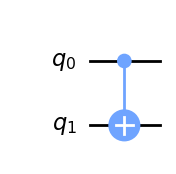

In [31]:
#Create 2-qubit state
qc3=QuantumCircuit(2)
#Operate cnot(cx) gate
qc3.cx(0,1)
#Visualize the circuit
qc3.draw('mpl', style="clifford")

<a id="Exercise_1"></a>
<div class="alert alert-block alert-success">

<b>Exercise 4: In the code cell below, create the state known as the Bell State!</b>

In this exercise, try creating a circuit that outputs the following the quantum state
</div>

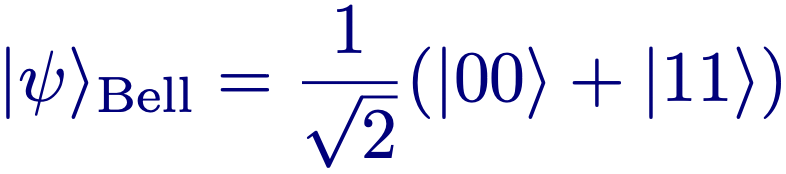

Circuit to generate a Bell state:


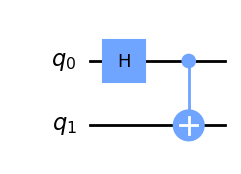

In [32]:
# Create a 2-qubit circuit
qc_ex4 = QuantumCircuit(2)

### WRITE YOUR CODE BELOW HERE ###

qc_ex4.h(0)
qc_ex4.cx(0,1)

### WRITE YOUR CODE ABOVE HERE ###

# Display the circuit diagram
print("Circuit to generate a Bell state:")
qc_ex4.draw('mpl', style="clifford")

In [33]:
# grader, You can check your Answer by conducting this cell
from IPython.utils import io
from grader import grade_bell
with io.capture_output() as captured:
    grade_bell(qc_ex4)
english_output = captured.stdout.replace('不正解です', 'Incorrect').replace('正解です', 'Correct')
print(english_output)

Correct！



## Addition
One of the advantages of quantum computing is the superposition state. Finally, let's apply the knowledge we've learned to implement a circuit that performs addition in parallel using superposition!
### First, let's start with a simple calculation

Starting with a superposition state right away can be difficult, so let's first consider a process that can also be done with classical bits. For simplicity, we will consider the following calculation:

$$
|q_1 q_0\rangle \to |(q_1 \oplus q_0) q_0\rangle
$$

In other words, this is a calculation where the result of the addition is stored in the second qubit ($q_1$). Specifically, we are looking at a transformation where each state changes as follows:

$$
|00\rangle \to |00\rangle, \quad |01\rangle \to |11\rangle, \quad |10\rangle \to |10\rangle, \quad |11\rangle \to |01\rangle
$$

<a id="Exercise_5"></a>
<div class="alert alert-block alert-success">

<b>Exercise 5: Let's create a quantum circuit that performs addition in the code cell below!</b>

In this exercise, design the state by following these steps:

1.**Consider 2 qubits.**

2.**Create the state $|10\rangle$.**

3.**Think of a quantum gate that can calculate $|q_1 q_0\rangle \to |(q_0 \oplus q_1) q_0\rangle$ and apply it.**
</div>

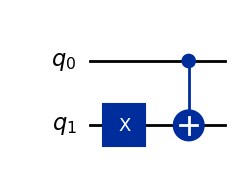

In [45]:
# Step 1: Create a 2-qubit circuit
qc_ex5 = QuantumCircuit(2)

### WRITE YOUR CODE BELOW HERE ###

# Step 2: Let's create the state |10>! (Hint: The current state is |00>)
qc_ex5.x(1)

# Step 3:
# Apply the gate that performs |q1 q0> -> |(q0+q1) q0>.
# (This gate was already introduced in the lecture!)
qc_ex5.cx(0,1)
### WRITE YOUR CODE ABOVE HERE ###

# Display the circuit diagram
display(qc_ex5.draw('mpl'))

In [46]:
# grader, You can check your Answer by conducting this cell
from IPython.utils import io
from grader import grade_sum1
with io.capture_output() as captured:
    grade_sum1(qc_ex5)
english_output = captured.stdout.replace('不正解です', 'Incorrect').replace('正解です', 'Correct')
print(english_output)

Correct！



Of course, addition can be performed on other quantum states as well, not just $|01\rangle$, using the same logic.Let's see if the circuit we created actually produces the expected results!

Measurement counts: {'10': 5000}


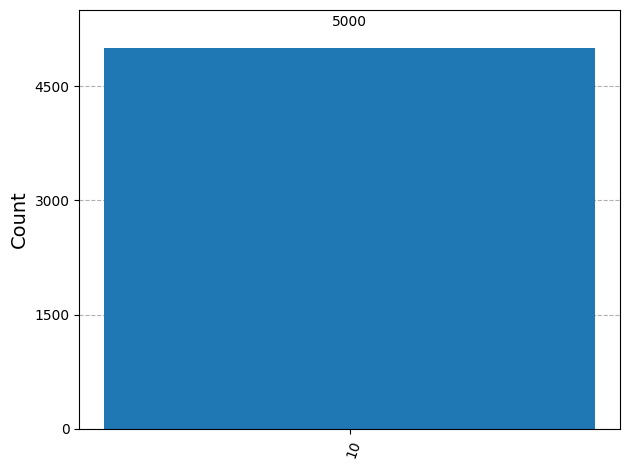

In [47]:
# Perform measurement and simulation
qc_ex5.measure_all()

# Select the simulator backend
# Instead of using actual quantum hardware, we use a backend that emulates its behavior.
backend = AerSimulator()

# Configure settings for transpilation and hardware-specific optimization
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
# Generate the optimized quantum circuit (ISA circuit)
isa_qc_ex5 = pm.run(qc_ex5)

# Define the Sampler primitive
# (While we're only sampling bitstrings here, Samplers are quite versatile
# and can even provide probability distributions directly.)
sampler = Sampler(mode=backend)

# Number of measurement shots
shots = 5000
# Execute the simulation using the configurations defined above
job = sampler.run([isa_qc_ex5], shots=shots)
result = job.result()

counts = result[0].data.meas.get_counts()
print(f'Measurement counts: {counts}')
hist = plot_histogram(counts)
hist

### **Performing Addition in Parallel**
A key feature of quantum computing is the ability to perform the addition above in parallel, calculating all $q_0 \oplus q_1$ operations at once. This can be expressed as:$$\sum_{q_0, q_1 = 0,1} |q_1 q_0\rangle \to \sum_{q_0, q_1 = 0,1} |(q_1 \oplus q_0) q_0\rangle$$To achieve this, we first need to create a superposition of all states (00, 01, 10, and 11) before performing the addition. Let's implement this in Exercise 6!

<a id="Exercise_6"></a>
<div class="alert alert-block alert-success">

<b>Exercise 6: Let's create a quantum circuit that performs addition in parallel!</b>

In this exercise, design the state by following these steps:

1.**Consider 2 qubits.**

2.**Apply quantum gates to one or both qubits to create a superposition where $|00\rangle, |01\rangle, |10\rangle,$ and $|11\rangle$ are observed uniformly. (Remember Exercise 3!)**

3.**Apply the addition operation you performed in Exercise 5!**
</div>

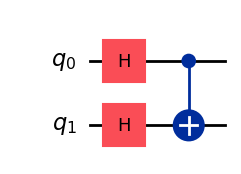

In [48]:
### WRITE YOUR CODE BELOW HERE ###

# Step 1: Create a 2-qubit circuit
qc_ex6 = QuantumCircuit(2)
# Step 2: Create a superposition of all states!
qc_ex6.h(0)
qc_ex6.h(1)
# Apply the gate that performs |q1 q0> -> |(q0+q1) q0>.
qc_ex6.cx(0,1)
### WRITE YOUR CODE ABOVE HERE ###

# Display the circuit diagram
display(qc_ex6.draw('mpl'))

In [49]:
# grader, You can check your Answer by conducting this cell
from IPython.utils import io
from grader import grade_sum2
with io.capture_output() as captured:
    grade_sum2(qc_ex6)
english_output = captured.stdout.replace('不正解です', 'Incorrect').replace('正解です', 'Correct')
print(english_output)

Correct！



Measurement counts: {'11': 1219, '00': 1256, '01': 1251, '10': 1274}


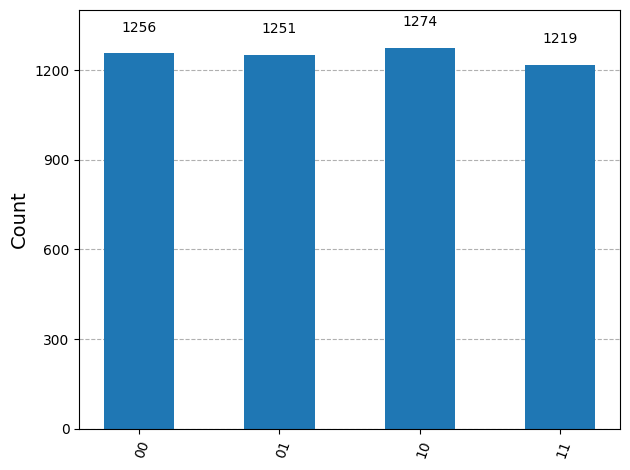

In [50]:
# Perform measurement and simulation
qc_ex6.measure_all()

# Select the simulator backend
# Instead of using actual quantum hardware, we use a backend that emulates its behavior.
backend = AerSimulator()

# Configure settings for transpilation and hardware-specific optimization
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
# Generate the optimized quantum circuit (ISA circuit)
isa_qc_ex6 = pm.run(qc_ex6)

# Define the Sampler primitive
# (While we're only sampling bitstrings here, Samplers are quite versatile
# and can even provide probability distributions directly.)
sampler = Sampler(mode=backend)

# Number of measurement shots
shots = 5000
# Execute the simulation using the configurations defined above
job = sampler.run([isa_qc_ex6], shots=shots)
result = job.result()

counts = result[0].data.meas.get_counts()
print(f'Measurement counts: {counts}')
hist = plot_histogram(counts)
hist

## Column: Experimenting on Actual Hardware

Up until now, we have been using simulators. However, with Qiskit, you can connect to actual quantum computer hardware owned by **IBM Quantum** and conduct real experiments. (Note: There are limits to the free tier available each month.)

By creating an account and obtaining an **API key**, you can access real quantum hardware. Instructions for creating an account (especially for students and faculty) can be found here: [https://quantum-tokyo.github.io/introduction/get_started/feature_code.html]